# Business Understanding

The MLP-GRU model offers small businesses an advanced solution for protecting their operations against cyber threats like malware. By analyzing network traffic patterns and behaviors, it identifies and prevents malicious software from disrupting operations, even if the malware is new or sophisticated. This proactive approach minimizes the risk of data breaches, financial loss, and downtime, which can be especially damaging for small businesses. Implementing such a system enhances customer trust, ensures regulatory compliance, and safeguards business continuity, making it a valuable investment for long-term growth and security in an increasingly digital landscape.

# Data Understanding

The dataset used for the MLP-GRU model comprises network flow characteristics, including features such as protocol type, packet size, flow duration, and TCP flags. These features capture both static and sequential aspects of network activity, which are critical for identifying malware behaviors. The dataset contains labels that classify each flow as either benign or malicious, enabling the model to learn patterns associated with different types of traffic. It also includes temporal features like flow inter-arrival times and packet rates, allowing the GRU component to analyze sequential dependencies. Understanding this data is essential for building a robust malware detection system capable of identifying both known and emerging threats.

In [1]:
import warnings
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from scipy import stats
from sklearn.preprocessing import StandardScaler
import warnings
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
import joblib
from collections import Counter
from keras.models import Model
from keras.layers import Input, Dense, Dropout, GRU, Concatenate
from keras.utils import to_categorical
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

2024-11-27 14:14:26.346504: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1732697066.399741    8199 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1732697066.415527    8199 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-11-27 14:14:26.465150: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Data Preparation

In [2]:
df = pd.read_csv("subset_dataset.csv")

In [3]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow IAT Mean,Bwd IAT Mean,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,...,SYN Flag Count,RST Flag Count,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Init_Win_bytes_forward,Init_Win_bytes_backward,Label,category
0,6.0,984922.0,3.0,2.0,2.462305e+05,40.0,96.0,64.0,3.045926,2.030618,...,1.0,0.0,114.400000,94.666667,2.0,3.0,1431.0,35.0,ADWARE_DOWGIN,AdwareMalware
1,6.0,985932.0,3.0,1.0,3.286440e+05,0.0,96.0,32.0,3.042806,1.014269,...,1.0,0.0,3.750000,1.666667,5.0,3.0,1386.0,9.0,ADWARE_DOWGIN,AdwareMalware
2,6.0,22538.0,1.0,2.0,1.126900e+04,253.0,32.0,64.0,44.369509,88.739019,...,0.0,0.0,10.333333,0.000000,15.5,1.0,2093.0,972.0,ADWARE_DOWGIN,AdwareMalware
3,6.0,31977.0,1.0,2.0,1.598850e+04,21.0,32.0,64.0,31.272477,62.544954,...,0.0,0.0,10.333333,0.000000,15.5,1.0,1641.0,972.0,ADWARE_DOWGIN,AdwareMalware
4,6.0,49401.0,1.0,1.0,4.940100e+04,0.0,32.0,32.0,20.242505,20.242505,...,0.0,0.0,0.000000,0.000000,0.0,1.0,1550.0,510.0,ADWARE_DOWGIN,AdwareMalware
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2576134,17.0,31241.0,1.0,1.0,3.124100e+04,0.0,20.0,32.0,32.009219,32.009219,...,0.0,0.0,112.500000,42.000000,141.0,1.0,-1.0,-1.0,SMSMALWARE_ZSONE,SmsMalware
2576135,17.0,198548.0,6.0,6.0,1.804982e+04,29245.8,188.0,224.0,30.219393,30.219393,...,0.0,0.0,804.916667,531.333333,853.5,6.0,-1.0,-1.0,SMSMALWARE_ZSONE,SmsMalware
2576136,17.0,1394.0,1.0,1.0,1.394000e+03,0.0,32.0,32.0,717.360115,717.360115,...,0.0,0.0,171.000000,48.000000,246.0,1.0,-1.0,-1.0,SMSMALWARE_ZSONE,SmsMalware
2576137,17.0,80848.0,1.0,1.0,8.084800e+04,0.0,32.0,32.0,12.368890,12.368890,...,0.0,0.0,87.000000,39.000000,96.0,1.0,-1.0,-1.0,SMSMALWARE_ZSONE,SmsMalware


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2576139 entries, 0 to 2576138
Data columns (total 22 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0    Protocol                 float64
 1    Flow Duration            float64
 2    Total Fwd Packets        float64
 3    Total Backward Packets   float64
 4    Flow IAT Mean            float64
 5    Bwd IAT Mean             float64
 6    Fwd Header Length        float64
 7    Bwd Header Length        float64
 8   Fwd Packets/s             float64
 9    Bwd Packets/s            float64
 10   Packet Length Variance   float64
 11  FIN Flag Count            float64
 12   SYN Flag Count           float64
 13   RST Flag Count           float64
 14   Average Packet Size      float64
 15   Avg Fwd Segment Size     float64
 16   Avg Bwd Segment Size     float64
 17  Subflow Fwd Packets       float64
 18  Init_Win_bytes_forward    float64
 19   Init_Win_bytes_backward  float64
 20   Label                  

In [5]:
df.columns = df.columns.str.strip()

In [6]:
df['Label'].nunique()

43

In [7]:
df['category'].nunique()

5

In [8]:
df["category"].value_counts()

category
Benign                1205515
AdwareMalware          424147
ScarewareMalware       375427
RansomewareMalware     348943
SmsMalware             222107
Name: count, dtype: int64

In [9]:
df.sample(10)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow IAT Mean,Bwd IAT Mean,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,...,SYN Flag Count,RST Flag Count,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Init_Win_bytes_forward,Init_Win_bytes_backward,Label,category
707067,6.0,23.0,1.0,1.0,2.300000e+01,0.000000,32.0,32.0,43478.260870,43478.260870,...,1.0,0.0,31.000000,31.000000,0.000000,1.0,1006.0,1006.0,BENIGN,Benign
2114313,6.0,247938.0,8.0,7.0,1.770986e+04,27879.000000,264.0,232.0,32.266131,28.232865,...,0.0,0.0,358.666667,124.000000,626.857143,8.0,65535.0,352.0,SCAREWARE_ANDROIDDEFENDER,ScarewareMalware
741437,6.0,8773598.0,2.0,0.0,8.773598e+06,0.000000,40.0,0.0,0.227957,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,1780.0,-1.0,BENIGN,Benign
1095150,6.0,2161.0,1.0,1.0,2.161000e+03,0.000000,20.0,20.0,462.748727,462.748727,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,29.0,1369.0,BENIGN,Benign
2105353,6.0,8008026.0,2.0,0.0,8.008026e+06,0.000000,40.0,0.0,0.249749,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,1552.0,-1.0,SCAREWARE_ANDROIDDEFENDER,ScarewareMalware
832547,17.0,376178.0,12.0,12.0,1.635557e+04,23056.636364,372.0,384.0,31.899792,31.899792,...,0.0,0.0,459.125000,451.916667,353.833333,12.0,-1.0,-1.0,BENIGN,Benign
824250,6.0,502737.0,10.0,8.0,2.957276e+04,58782.857143,328.0,264.0,19.891116,15.912893,...,0.0,0.0,308.722222,117.400000,547.875000,10.0,65535.0,362.0,BENIGN,Benign
272478,6.0,7150615.0,2.0,0.0,7.150615e+06,0.000000,40.0,0.0,0.279696,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,1369.0,-1.0,ADWARE_KOODOUS,AdwareMalware
2485712,6.0,28.0,2.0,0.0,2.800000e+01,0.000000,64.0,0.0,71428.571429,0.000000,...,1.0,0.0,55.000000,27.500000,0.000000,2.0,362.0,-1.0,SMSMALWARE_NANDROBOX,SmsMalware
1730322,6.0,351234.0,3.0,0.0,1.756170e+05,0.000000,96.0,0.0,8.541314,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,3.0,1460.0,-1.0,RANSOMWARE_KOLER,RansomewareMalware


In [10]:
df['RST Flag Count'].nunique()

2

In [11]:
df.isnull().sum()

Protocol                    0
Flow Duration               0
Total Fwd Packets           0
Total Backward Packets      0
Flow IAT Mean               1
Bwd IAT Mean                2
Fwd Header Length           3
Bwd Header Length           3
Fwd Packets/s               3
Bwd Packets/s               4
Packet Length Variance      6
FIN Flag Count              6
SYN Flag Count              6
RST Flag Count              6
Average Packet Size         9
Avg Fwd Segment Size        9
Avg Bwd Segment Size        9
Subflow Fwd Packets        10
Init_Win_bytes_forward     10
Init_Win_bytes_backward    10
Label                      11
category                    0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df = df.drop_duplicates()

In [14]:
label_encoder = LabelEncoder()

df['Label_encoded'] = label_encoder.fit_transform(df['Label'])

df['category_encoded'] = label_encoder.fit_transform(df['category'])

df = df.drop(columns=['Label', 'category'])

In [15]:
df

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow IAT Mean,Bwd IAT Mean,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,...,SYN Flag Count,RST Flag Count,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Init_Win_bytes_forward,Init_Win_bytes_backward,Label_encoded,category_encoded
0,6.0,984922.0,3.0,2.0,2.462305e+05,40.0,96.0,64.0,3.045926,2.030618,...,1.0,0.0,114.400000,94.666667,2.0,3.0,1431.0,35.0,0,0
1,6.0,985932.0,3.0,1.0,3.286440e+05,0.0,96.0,32.0,3.042806,1.014269,...,1.0,0.0,3.750000,1.666667,5.0,3.0,1386.0,9.0,0,0
2,6.0,22538.0,1.0,2.0,1.126900e+04,253.0,32.0,64.0,44.369509,88.739019,...,0.0,0.0,10.333333,0.000000,15.5,1.0,2093.0,972.0,0,0
3,6.0,31977.0,1.0,2.0,1.598850e+04,21.0,32.0,64.0,31.272477,62.544954,...,0.0,0.0,10.333333,0.000000,15.5,1.0,1641.0,972.0,0,0
4,6.0,49401.0,1.0,1.0,4.940100e+04,0.0,32.0,32.0,20.242505,20.242505,...,0.0,0.0,0.000000,0.000000,0.0,1.0,1550.0,510.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2576134,17.0,31241.0,1.0,1.0,3.124100e+04,0.0,20.0,32.0,32.009219,32.009219,...,0.0,0.0,112.500000,42.000000,141.0,1.0,-1.0,-1.0,42,4
2576135,17.0,198548.0,6.0,6.0,1.804982e+04,29245.8,188.0,224.0,30.219393,30.219393,...,0.0,0.0,804.916667,531.333333,853.5,6.0,-1.0,-1.0,42,4
2576136,17.0,1394.0,1.0,1.0,1.394000e+03,0.0,32.0,32.0,717.360115,717.360115,...,0.0,0.0,171.000000,48.000000,246.0,1.0,-1.0,-1.0,42,4
2576137,17.0,80848.0,1.0,1.0,8.084800e+04,0.0,32.0,32.0,12.368890,12.368890,...,0.0,0.0,87.000000,39.000000,96.0,1.0,-1.0,-1.0,42,4


## Handling Outliers

### Z-Score Outlier Removal

In [16]:
numeric_df = df.select_dtypes(include=[np.number])

z_scores = np.abs(stats.zscore(numeric_df))

threshold = 3

outliers = (z_scores > threshold)

outlier_rows = np.any(outliers, axis=1)

df = df[~outlier_rows]

df.reset_index(drop=True, inplace=True)

In [17]:
df.sample(10)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Flow IAT Mean,Bwd IAT Mean,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,...,SYN Flag Count,RST Flag Count,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Subflow Fwd Packets,Init_Win_bytes_forward,Init_Win_bytes_backward,Label_encoded,category_encoded
1434287,6.0,6971282.0,2.0,0.0,6.971282e+06,0.000000,40.0,0.0,0.286891,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,65535.0,-1.0,20,2
1147172,6.0,731023.0,13.0,12.0,3.045929e+04,58649.090909,424.0,392.0,17.783298,16.415352,...,0.0,0.0,351.320000,317.538462,387.916667,13.0,65535.0,413.0,10,1
245780,6.0,414.0,2.0,0.0,4.140000e+02,0.000000,40.0,0.0,4830.917874,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,115.0,-1.0,6,0
1263618,6.0,129.0,2.0,0.0,1.290000e+02,0.000000,40.0,0.0,15503.875969,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,2.0,1772.0,-1.0,12,2
522400,17.0,261781.0,1.0,1.0,2.617810e+05,0.000000,32.0,20.0,3.819987,3.819987,...,0.0,0.0,92.500000,33.000000,119.000000,1.0,-1.0,-1.0,10,1
1397789,17.0,665711.0,1.0,1.0,6.657110e+05,0.000000,20.0,40.0,1.502153,1.502153,...,0.0,0.0,79.000000,37.000000,84.000000,1.0,-1.0,-1.0,18,2
1922168,6.0,19519048.0,8.0,7.0,1.394218e+06,36395.500000,264.0,232.0,0.409856,0.358624,...,0.0,0.0,282.600000,42.375000,557.142857,8.0,65535.0,118.0,40,4
178135,6.0,20006439.0,6.0,4.0,2.222938e+06,53695.666667,200.0,136.0,0.299903,0.199936,...,0.0,0.0,89.900000,122.166667,41.500000,6.0,65535.0,349.0,4,0
1049535,6.0,36605.0,1.0,1.0,3.660500e+04,0.000000,32.0,32.0,27.318672,27.318672,...,0.0,0.0,0.000000,0.000000,0.000000,1.0,2041.0,365.0,10,1
232747,6.0,4921159.0,13.0,9.0,2.343409e+05,610725.750000,424.0,296.0,2.641654,1.828837,...,0.0,0.0,223.136364,209.307692,243.111111,13.0,65535.0,135.0,5,0


Class Distribution:
category_encoded
1    919708
0    327673
3    291837
2    272452
4    171035
Name: count, dtype: int64


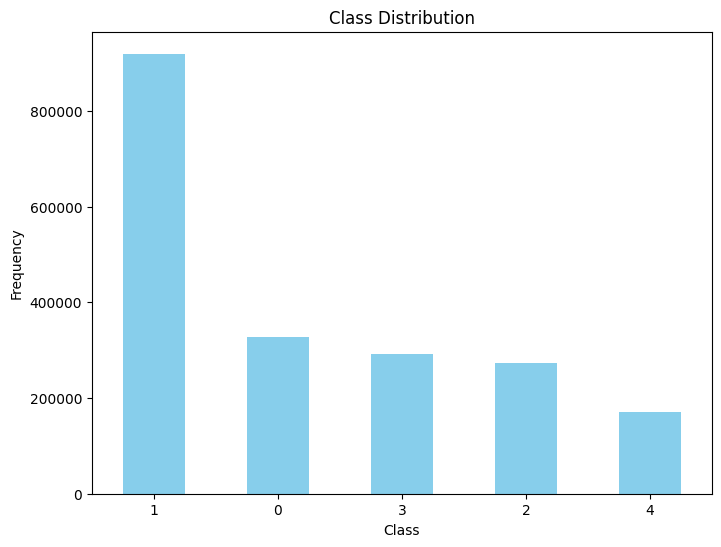

In [18]:
class_distribution = df['category_encoded'].value_counts()

# Print the class counts
print("Class Distribution:")
print(class_distribution)

# Plot the class distribution
plt.figure(figsize=(8, 6))
class_distribution.plot(kind='bar', color='skyblue')
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

## Feature Scaling:

## Balance the dataset:

In [19]:
target_class_count = 400000  # Target count for class 1

# Separate each class into its own DataFrame
class_0 = df[df['category_encoded'] == 0]
class_1 = df[df['category_encoded'] == 1]
class_2 = df[df['category_encoded'] == 2]
class_3 = df[df['category_encoded'] == 3]
class_4 = df[df['category_encoded'] == 4]

# Downsample class 1 to the target count (4 lakh samples)
class_1_downsampled = class_1.sample(n=target_class_count, random_state=42)

# Combine the downsampled class 1 with the other classes (class 0, 2, 3, and 4 are kept as is)
df_balanced = pd.concat([class_0, class_1_downsampled, class_2, class_3, class_4])

# Shuffle the final DataFrame to mix the classes well
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify the class distribution after downsampling
print(df_balanced['category_encoded'].value_counts())

category_encoded
1    400000
0    327673
3    291837
2    272452
4    171035
Name: count, dtype: int64


### Standard Scalar

In [19]:
X = df.drop(columns=['category_encoded'])  # Independent variables
y = df['category_encoded']                # Target variable

# Step 2: Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Smote

In [20]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_scaled, y)

# Step 4: Check class distribution after SMOTE
print("Before SMOTE:", Counter(y))
print("After SMOTE:", Counter(y_resampled))

Before SMOTE: Counter({1: 1816, 0: 652, 2: 541, 3: 533, 4: 335})
After SMOTE: Counter({0: 1816, 2: 1816, 1: 1816, 4: 1816, 3: 1816})


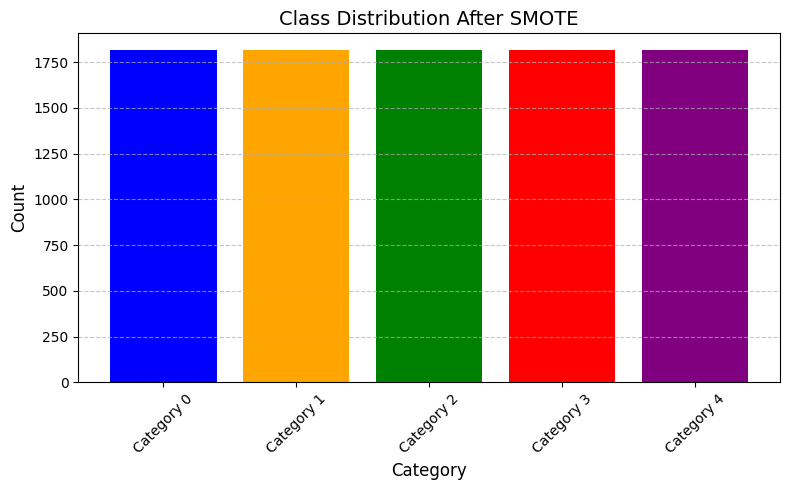

In [30]:
target_counts = {
    "Category 0": 1816,
    "Category 1": 1816,
    "Category 2": 1816,
    "Category 3": 1816,
    "Category 4": 1816,
}

# Plotting the bar chart
categories = list(target_counts.keys())
counts = list(target_counts.values())

plt.figure(figsize=(8, 5))
plt.bar(categories, counts, color=['blue', 'orange', 'green', 'red', 'purple'])

plt.title("Class Distribution After SMOTE", fontsize=14)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [22]:
# Step 5: Split the resampled data into training and testing sets
X_train_resampled, X_test, y_train_resampled, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

# Step 6: Reshape data for GRU (time-series format)
X_train_gru = np.reshape(X_train_resampled, (X_train_resampled.shape[0], 1, X_train_resampled.shape[1]))
X_test_gru = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

# Step 7: One-hot encode the target labels for multi-class classification
num_classes = len(np.unique(y))  # Automatically determine the number of classes
y_train_categorical = to_categorical(y_train_resampled, num_classes=num_classes)
y_test_categorical = to_categorical(y_test, num_classes=num_classes)

# Step 8: Define the MLP model
mlp_input = Input(shape=(X_train_resampled.shape[1],))  # MLP uses 2D input (samples, features)
mlp_layer1 = Dense(32, activation='relu')(mlp_input)  # Increased complexity for MLP
mlp_dropout1 = Dropout(0.5)(mlp_layer1)
mlp_output = Dense(32, activation='relu')(mlp_dropout1)

# Step 9: Define the GRU model
gru_input = Input(shape=(X_train_gru.shape[1], X_train_gru.shape[2]))  # GRU uses 3D input (samples, timesteps, features)
gru_layer1 = GRU(32)(gru_input)  # Increased complexity for GRU
gru_dropout1 = Dropout(0.5)(gru_layer1)

# Step 10: Concatenate the outputs of MLP and GRU
merged = Concatenate()([mlp_output, gru_dropout1])

# Step 11: Output layer for multi-class classification
output = Dense(num_classes, activation='softmax')(merged)

# Step 12: Create the hybrid MLP + GRU model
model = Model(inputs=[mlp_input, gru_input], outputs=output)

# Step 13: Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Step 14: Train the model
history = model.fit(
    [X_train_resampled, X_train_gru],  # Inputs: MLP and GRU
    y_train_categorical,  # Target labels
    epochs=10,  # Adjust epochs as needed
    batch_size=16,  # Adjust batch size as needed
    validation_data=([X_test, X_test_gru], y_test_categorical),  # Validation data
    verbose=1
)

2024-11-21 17:27:44.608103: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.3833 - loss: 1.3978 - val_accuracy: 0.7731 - val_loss: 0.7316
Epoch 2/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7095 - loss: 0.7445 - val_accuracy: 0.9080 - val_loss: 0.4314
Epoch 3/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8197 - loss: 0.5101 - val_accuracy: 0.9224 - val_loss: 0.3024
Epoch 4/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8856 - loss: 0.3648 - val_accuracy: 0.9466 - val_loss: 0.2138
Epoch 5/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8994 - loss: 0.3083 - val_accuracy: 0.9637 - val_loss: 0.1737
Epoch 6/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9171 - loss: 0.2679 - val_accuracy: 0.9719 - val_loss: 0.1519
Epoch 7/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9362 - loss: 0.2175 - val_accuracy: 0.9719 - val_loss: 0.1274
Epoch 8/10
454/454 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9418 - loss: 0.2003 - val_accuracy: 

## Model accuracy And Model loss

Test Loss: 0.10519928485155106
Test Accuracy: 0.9768722653388977


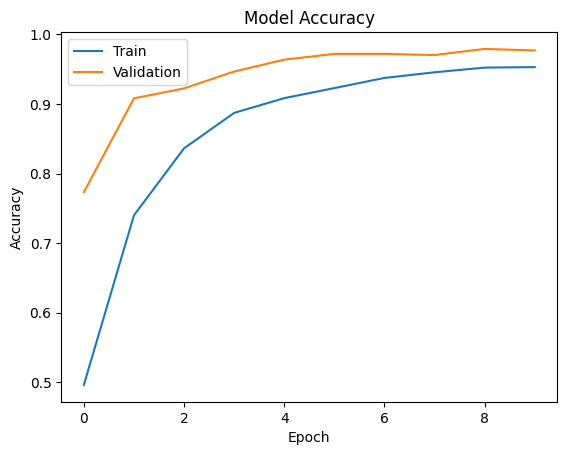

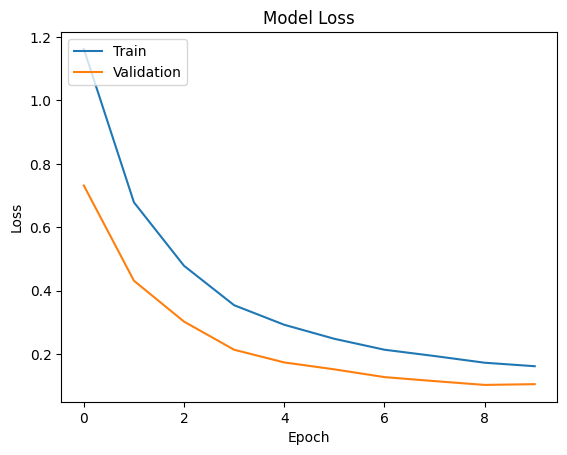

In [24]:
# Step 14: Evaluate the model on the test data
loss, accuracy = model.evaluate([X_test, X_test_gru], y_test_categorical, verbose=0)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy}")

# Step 15: Plot the training history
# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

## Confusion Matrix

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


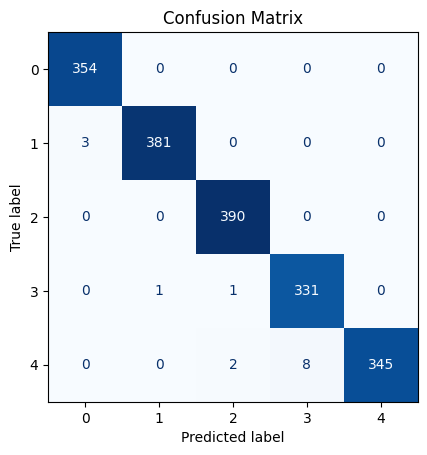

In [33]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions
y_pred = model.predict([X_test, X_test_gru])
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Display the confusion matrix as a diagram without colorbar
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_true))
fig, ax = plt.subplots()
disp.plot(cmap='Blues', values_format='d', ax=ax, colorbar=False)
plt.title("Confusion Matrix")
plt.show()


## Classification Report

In [26]:
from sklearn.metrics import classification_report

print("Classification Report:")
print(classification_report(y_true, y_pred_classes))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98       354
           1       0.96      1.00      0.98       384
           2       0.99      0.98      0.99       390
           3       0.94      0.99      0.96       333
           4       0.99      0.96      0.98       355

    accuracy                           0.98      1816
   macro avg       0.98      0.98      0.98      1816
weighted avg       0.98      0.98      0.98      1816



## ROC-AUC Curve (for Multi-Class)

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


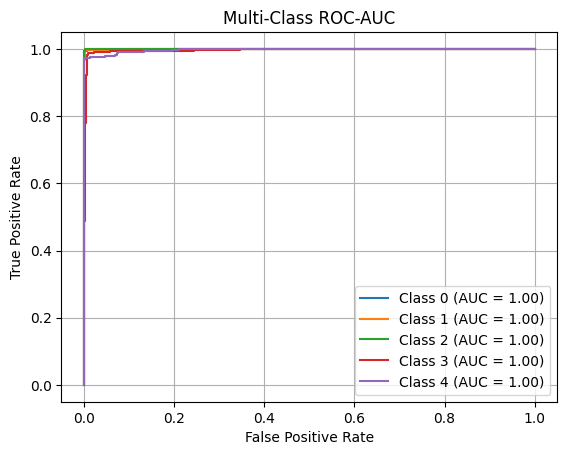

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize the labels for ROC calculation
y_test_bin = label_binarize(y_true, classes=np.unique(y_true))
y_pred_prob = model.predict([X_test, X_test_gru])

# Compute ROC curve and AUC for each class
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.title("Multi-Class ROC-AUC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

## Cross-Validation

In [28]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies = []

for train_idx, val_idx in skf.split(X_resampled, y_resampled):
    X_train_fold, X_val_fold = X_resampled[train_idx], X_resampled[val_idx]
    y_train_fold, y_val_fold = y_resampled[train_idx], y_resampled[val_idx]
    
    # Reshape for GRU
    X_train_fold_gru = np.reshape(X_train_fold, (X_train_fold.shape[0], 1, X_train_fold.shape[1]))
    X_val_fold_gru = np.reshape(X_val_fold, (X_val_fold.shape[0], 1, X_val_fold.shape[1]))

    # Train the model
    model.fit([X_train_fold, X_train_fold_gru], to_categorical(y_train_fold, num_classes),
              batch_size=16, epochs=10, verbose=0)

    # Evaluate on the validation fold
    val_predictions = model.predict([X_val_fold, X_val_fold_gru])
    val_accuracy = accuracy_score(np.argmax(to_categorical(y_val_fold, num_classes), axis=1),
                                   np.argmax(val_predictions, axis=1))
    fold_accuracies.append(val_accuracy)

print(f"Cross-Validation Accuracies: {fold_accuracies}")
print(f"Average Cross-Validation Accuracy: {np.mean(fold_accuracies):.2f}")

57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Cross-Validation Accuracies: [0.9834801762114538, 0.9911894273127754, 0.9807268722466961, 0.987885462555066, 0.9900881057268722]
Average Cross-Validation Accuracy: 0.99


## Actual vs Predicted Congestion Labels for Sample Test Data

In [29]:
# Reset index of y_test for consistency
y_test_reset_index = y_test.reset_index(drop=True)

# Take the first 20 values from the test set
X_sample = X_test[5:25]  # Sample from the test set
y_actual = y_test_reset_index[5:25]

# Reshape the X_sample for both MLP and GRU inputs
X_sample_gru = np.reshape(X_sample, (X_sample.shape[0], 1, X_sample.shape[1]))

# Predict congestion labels for the sampled data using both MLP and GRU
y_pred_prob_sample = model.predict([X_sample, X_sample_gru])  # Use MLP and GRU inputs together
y_pred_sample = np.argmax(y_pred_prob_sample, axis=1)  # Get predicted classes

# Print actual vs predicted labels for the sample
print("Actual vs Predicted Congestion Labels:")
for i in range(20):
    print(f"Actual: {y_actual.iloc[i]}, Predicted: {y_pred_sample[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Actual vs Predicted Congestion Labels:
Actual: 0, Predicted: 0
Actual: 1, Predicted: 1
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 4, Predicted: 4
Actual: 2, Predicted: 2
Actual: 4, Predicted: 4
Actual: 4, Predicted: 4
Actual: 0, Predicted: 0
Actual: 3, Predicted: 3
Actual: 4, Predicted: 4
Actual: 2, Predicted: 2
Actual: 1, Predicted: 1
Actual: 1, Predicted: 1
Actual: 3, Predicted: 3
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
Actual: 0, Predicted: 0
